# RCADS symptom scores and ACR summed BCA

## TL;DR

This exploratory analysis joined all 35 ACR EEG participants to their verified RCADS-47 scores and tested six RCADS subscales against every one of 54 condition × ROI raw summed-BCA cells. Nine Pearson correlations survived Benjamini–Hochberg false-discovery-rate correction in the audit-inclusive data. They were not robust: all nine were most influenced by P27, none of 324 Spearman correlations survived correction, and no Pearson discovery remained after omitting P27. Condition-specific random-intercept mixed models showed the same pattern, with corrected effects in the full data but none after P27 was omitted. The defensible conclusion is therefore **no reliable RCADS–BCA association was established in this dataset**; the unrobust separation-anxiety/ROT pattern is a follow-up target, not a result ready for substantive interpretation.

This notebook is an audit companion. It runs the adjacent `run_rcads_bca_analysis.py` script, displays the principal outputs, and preserves all correlation tables as CSV files.

## Context and methods

The EEG outcome was **Raw Summed mean BCA** from `ACR Data.xlsx`. Each test used one value per participant for one condition × ROI cell; repeated rows were not treated as independent observations. The six primary predictors were RCADS raw subscale scores: Social Phobia, Panic Disorder, Major Depression, Separation Anxiety, Generalized Anxiety, and Obsessive Compulsive. Raw scores were primary because their T-score versions are deterministic, norm-adjusted transformations and correlated at approximately .98–.995 with raw scores in this sample.

For each of 324 prespecified cells (6 scores × 9 conditions × 6 ROIs), a two-sided Pearson correlation, Fisher-transformed 95% confidence interval, and two-sided Spearman rank correlation were calculated. Benjamini–Hochberg FDR correction was applied across the complete 324-test primary family. Benjamini–Yekutieli and Holm adjustments were retained as stricter sensitivities. Exact per-cell sample sizes were retained; cells with N < 20 were marked descriptive. No missing condition was imputed.

Robustness checks comprised Spearman correlation, leave-one-participant-out recalculation, median-absolute-deviation BCA flags, workbook-QC exclusions, omission of P27, RCADS T scores, age/sex-adjusted partial correlations, official raw composite scores, and condition-specific mixed-effects likelihood-ratio tests. The mixed model compared `BCA ~ ROI` with `BCA ~ ROI × standardized RCADS score`, using participant as a random intercept; 54 omnibus tests were FDR-corrected. A secondary ROT−LOT lateralization scan was kept separate from the primary amplitude family.

The anxious/non-anxious project label was not used as an independent covariate because it was reconstructed perfectly by `Total Anxiety Raw ≥ 21` in these 35 participants. Conditioning on that derived group would remove part of the continuous predictor and impose range restriction.

Method references: [official UCLA RCADS scoring](https://rcads.ucla.edu/manualscoring), [Pearson correlation documentation](https://docs.scipy.org/doc/scipy/tutorial/stats/hypothesis_pearsonr.html), [Spearman correlation documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html), [Benjamini and Hochberg (1995)](https://doi.org/10.1111/j.2517-6161.1995.tb02031.x), and [statsmodels mixed-effects documentation](https://www.statsmodels.org/stable/mixed_linear.html).

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display

OUTPUT_DIR = Path.cwd()
SCRIPT = OUTPUT_DIR / "run_rcads_bca_analysis.py"
completed = subprocess.run(
    [sys.executable, str(SCRIPT)],
    cwd=OUTPUT_DIR,
    check=True,
    capture_output=True,
    text=True,
)
print(completed.stdout)

                                                 Check Value
                                      ACR participants    35
                                    RCADS participants    40
                              Matched ACR participants    35
                                         ACR long rows  1464
                                            Conditions     9
                                                  ROIs     6
                      Duplicate PID-condition-ROI keys     0
                                Missing raw BCA values     0
Group exactly reconstructed by Total Anxiety Raw >= 21  True

Sensitivity summary
                                                    Variant  Tests  Minimum N  Maximum N  Pearson BH-FDR Discoveries  Pearson BY-FDR Discoveries  Pearson Holm Discoveries  Spearman BH-FDR Discoveries
                           All audit data; raw RCADS scores    324         12         35                           9                           5                         

## Data audit

In [2]:
audit = pd.read_csv(OUTPUT_DIR / "data_audit.csv")
condition_n = pd.read_csv(OUTPUT_DIR / "condition_sample_sizes.csv")
group_n = pd.read_csv(OUTPUT_DIR / "group_sample_sizes.csv")
display(audit)
display(group_n)
display(condition_n)

,Check,Value
0,ACR participants,35
1,RCADS participants,40
2,Matched ACR participants,35
3,ACR long rows,1464
4,Conditions,9
5,ROIs,6
6,Duplicate PID-condition-ROI keys,0
7,Missing raw BCA values,0
8,Group exactly reconstructed by Total Anxiety R...,True


,Group,N Participants
0,anxious,18
1,non-anxious,17


,Condition,N Participants
0,Angry Caucasian,22
1,Happy Caucasian,22
2,Angry Neutral,13
3,Neutral Fear,12
4,Negative Valence,35
5,Neutral Angry,35
6,Neutral Happy,35
7,Neutral Sad,35
8,Positive Valence,35


The join was complete for all ACR participants: 35 EEG participants matched unique RCADS records, with no duplicate condition × ROI cells and no missing raw BCA. The five common conditions had N=35; the two Caucasian conditions had N=22; Angry Neutral and Neutral Fear had N=13 and N=12 and are descriptive because they are underpowered. Workbook QC flags identify P20 globally and P1/P4 for Negative Valence; those observations are present in the audit workbook and were handled in sensitivity analyses.

## Primary correlation family

In [3]:
primary = pd.read_csv(OUTPUT_DIR / "primary_raw_correlations.csv")
discoveries = primary.loc[primary["Pearson_q_bh"] < .05].sort_values("Pearson p")
display(discoveries[[
    "Condition", "ROI", "RCADS Scale", "N", "Pearson r",
    "Pearson CI 95% Low", "Pearson CI 95% High", "Pearson p", "Pearson_q_bh",
    "Spearman rho", "Spearman_q_bh", "Most Influential PID",
    "Pearson r Without Most Influential PID"
]].round(4))

,Condition,ROI,RCADS Scale,N,Pearson r,Pearson CI 95% Low,Pearson CI 95% High,Pearson p,Pearson_q_bh,Spearman rho,Spearman_q_bh,Most Influential PID,Pearson r Without Most Influential PID
225,Negative Valence,ROT,Separation Anxiety,35,-0.6878,-0.8307,-0.4600,0.0000,0.0009,-0.3526,0.5097,P27,-0.3209
261,Angry Caucasian,ROT,Separation Anxiety,22,0.8002,0.5713,0.9136,0.0000,0.0009,0.3095,0.8270,P27,0.3338
297,Happy Caucasian,ROT,Separation Anxiety,22,-0.7986,-0.9128,-0.5683,0.0000,0.0009,-0.3165,0.8160,P27,-0.2267
189,Positive Valence,ROT,Separation Anxiety,35,0.6506,0.4052,0.8085,0.0000,0.0019,0.1631,0.9671,P27,0.1349
117,Neutral Happy,ROT,Separation Anxiety,35,0.6088,0.3457,0.7832,0.0001,0.0067,-0.1324,0.9817,P27,-0.1122
153,Neutral Sad,ROT,Separation Anxiety,35,0.5926,0.3232,0.7732,0.0002,0.0095,0.1054,0.9830,P27,-0.0383
45,Neutral Angry,ROT,Separation Anxiety,35,-0.5723,-0.7605,-0.2954,0.0003,0.0152,-0.0410,0.9830,P27,0.0931
267,Angry Caucasian,O,Separation Anxiety,22,0.6888,0.3765,0.8605,0.0004,0.0159,0.4542,0.4950,P27,0.4179
226,Negative Valence,ROT,Generalized Anxiety,35,-0.5343,-0.7364,-0.2446,0.0009,0.0341,-0.2362,0.8270,P27,-0.2365


Nine Pearson correlations survived BH-FDR. Eight involved Separation Anxiety and one involved Generalized Anxiety. Most were in ROT, and the signs varied sharply by condition. The sign reversals are not a coherent dose-response pattern: they mirror the unusually large positive and negative ROT values of one high-scoring participant, P27.

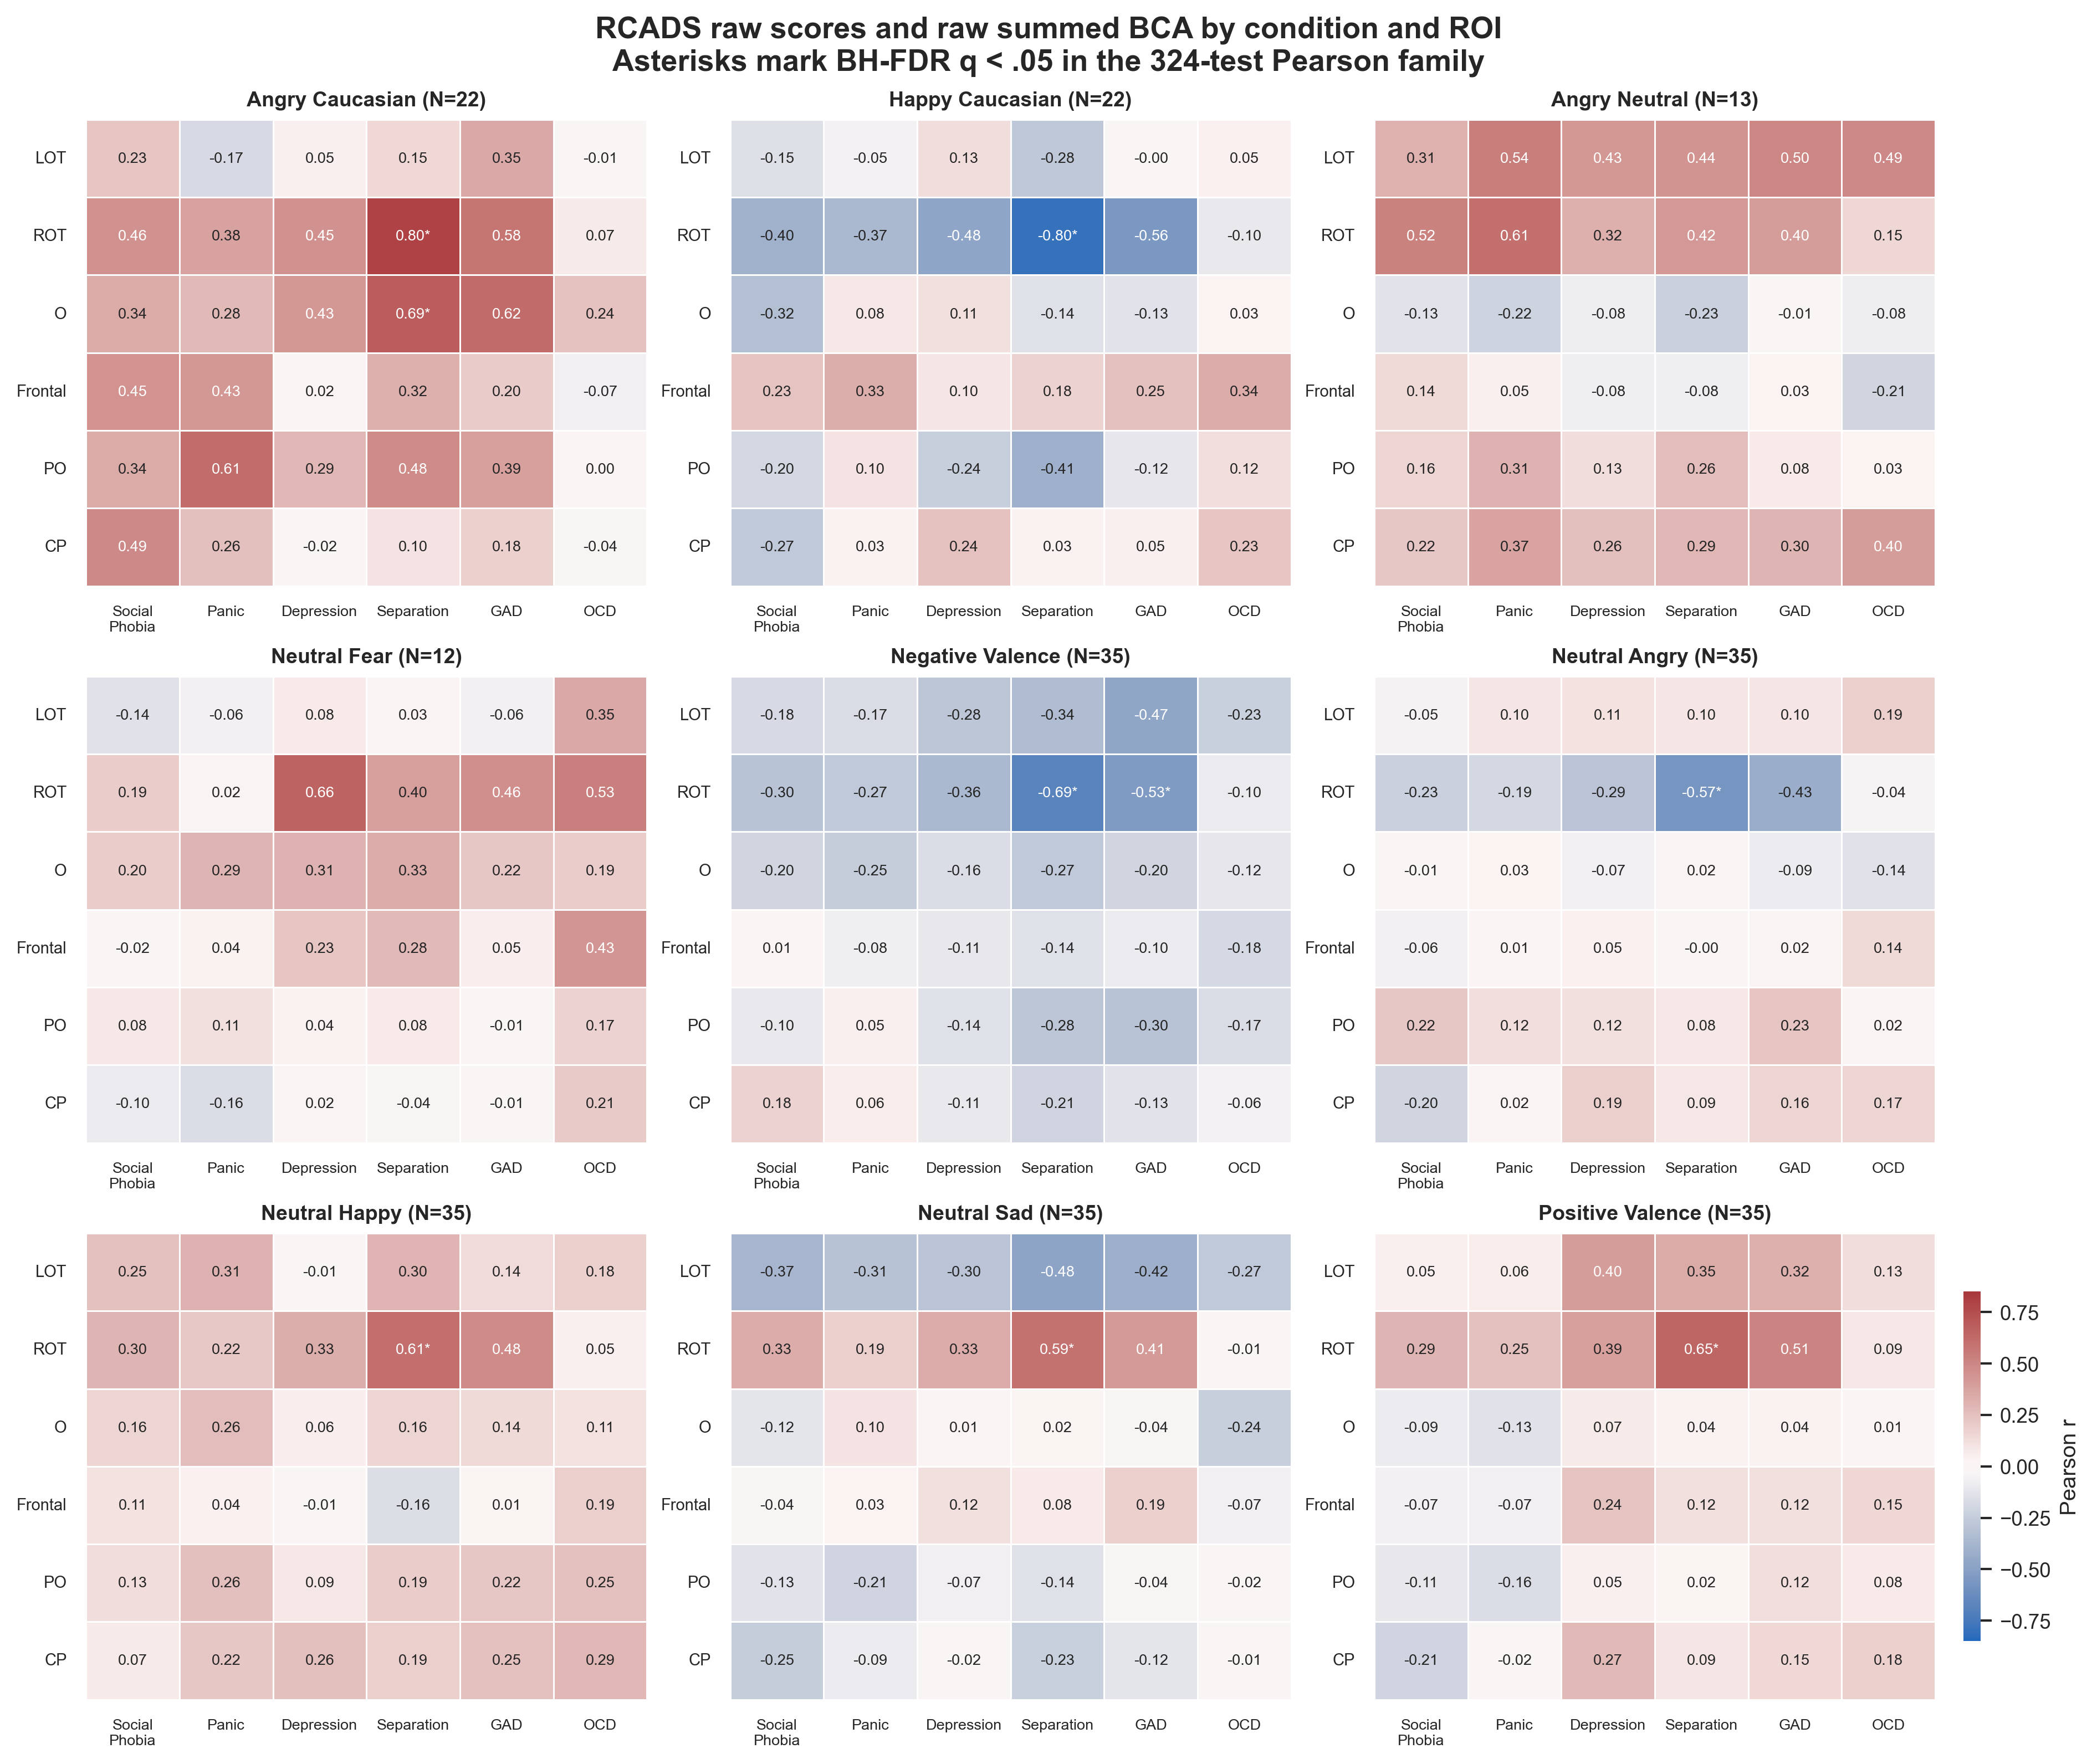

In [4]:
display(Image(filename=str(OUTPUT_DIR / "pearson_correlation_heatmap.png"), width=1100))

## Robustness and influence

In [5]:
sensitivity = pd.read_csv(OUTPUT_DIR / "sensitivity_summary.csv")
display(sensitivity)

,Variant,Tests,Minimum N,Maximum N,Pearson BH-FDR Discoveries,Pearson BY-FDR Discoveries,Pearson Holm Discoveries,Spearman BH-FDR Discoveries
0,All audit data; raw RCADS scores,324,12,35,9,5,5,0.0
1,P27 omitted; raw RCADS scores,324,12,34,0,0,0,0.0
2,Workbook QC flags honored; raw RCADS scores,324,12,34,10,4,4,0.0
3,Workbook QC flags honored and P27 omitted; raw...,324,12,33,0,0,0,0.0
4,All audit data; RCADS T scores,324,12,35,8,4,5,0.0
5,P27 omitted; RCADS T scores,324,12,34,0,0,0,0.0
6,All audit data; RCADS raw composites,108,12,35,0,0,0,0.0
7,P27 omitted; RCADS raw composites,108,12,34,0,0,0,0.0
8,All audit data; raw RCADS; age/sex adjusted,324,12,35,8,5,5,NaN
9,P27 omitted; raw RCADS; age/sex adjusted,324,12,34,0,0,0,NaN


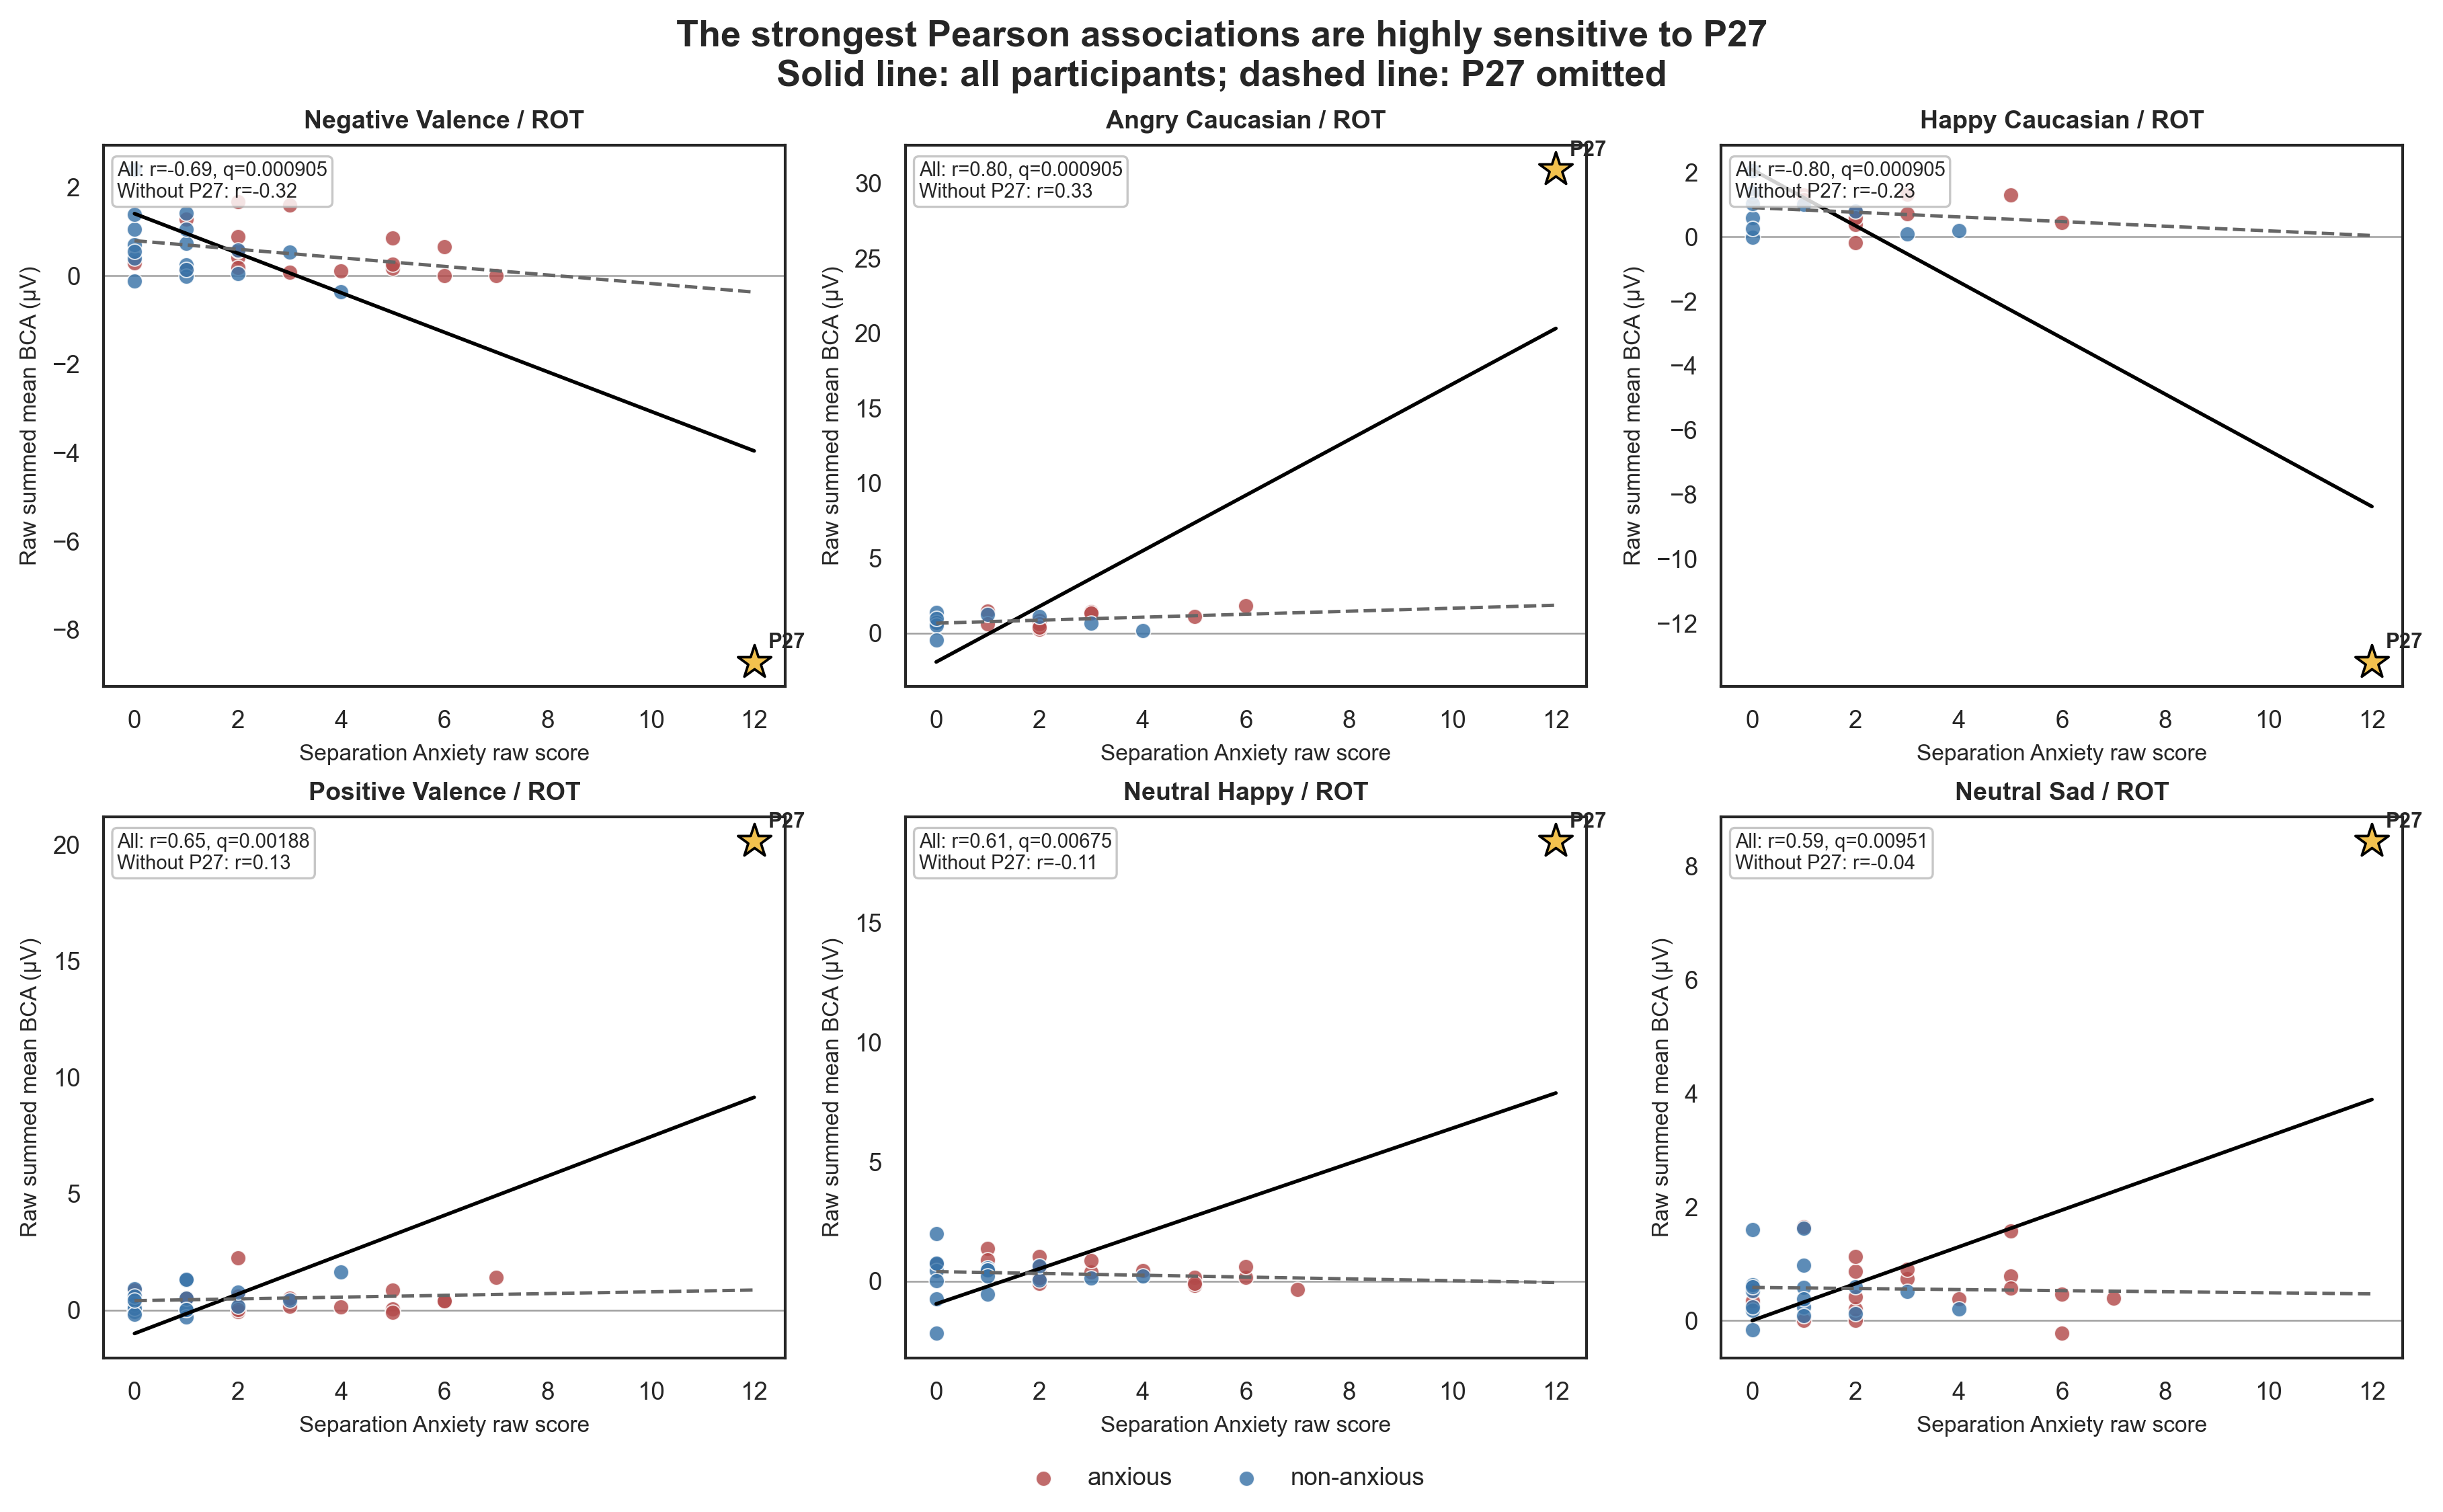

In [6]:
display(Image(filename=str(OUTPUT_DIR / "influence_of_P27.png"), width=1100))

The robust checks do not support the apparent Pearson discoveries. No Spearman correlation survived FDR correction. P27 was the most influential participant for every primary Pearson discovery; after P27 was omitted, all 324 Pearson discoveries disappeared. The same happened after combining P27 omission with the workbook QC exclusions. T scores and age/sex-adjusted partial correlations reproduced the full-data Pearson pattern but also produced no corrected finding after P27 omission. This indicates that demographic adjustment or score normalization cannot solve the influence problem.

## Repeated-measures mixed-model check

In [7]:
lmm = pd.read_csv(OUTPUT_DIR / "condition_specific_lmm_omnibus.csv")
lmm_summary = (
    lmm.groupby("Variant")
    .agg(
        Models=("p", "count"),
        Converged=("Converged", "sum"),
        FDR_discoveries=("LMM Omnibus_q_bh", lambda x: int((x < .05).sum())),
    )
    .reset_index()
)
display(lmm_summary)
display(lmm.sort_values(["Variant", "p"]).groupby("Variant").head(8)[[
    "Variant", "Condition", "RCADS Scale", "N Participants",
    "Likelihood-Ratio Chi-Square", "Degrees of Freedom", "p", "LMM Omnibus_q_bh"
]].round(5))

,Variant,Models,Converged,FDR_discoveries
0,All audit data,54,54,24
1,P27 omitted,54,54,0


,Variant,Condition,RCADS Scale,N Participants,Likelihood-Ratio Chi-Square,Degrees of Freedom,p,LMM Omnibus_q_bh
45,All audit data,Angry Caucasian,Separation Anxiety,22,125.09834,6,0.00000,0.00000
51,All audit data,Happy Caucasian,Separation Anxiety,22,100.12942,6,0.00000,0.00000
21,All audit data,Neutral Happy,Separation Anxiety,35,69.25597,6,0.00000,0.00000
27,All audit data,Neutral Sad,Separation Anxiety,35,59.74979,6,0.00000,0.00000
33,All audit data,Positive Valence,Separation Anxiety,35,57.60655,6,0.00000,0.00000
46,All audit data,Angry Caucasian,Generalized Anxiety,22,50.94493,6,0.00000,0.00000
52,All audit data,Happy Caucasian,Generalized Anxiety,22,40.52994,6,0.00000,0.00000
22,All audit data,Neutral Happy,Generalized Anxiety,35,39.46238,6,0.00000,0.00000
104,P27 omitted,Happy Caucasian,Major Depression,21,17.03921,6,0.00914,0.49357
105,P27 omitted,Happy Caucasian,Separation Anxiety,21,14.04753,6,0.02911,0.78596


The condition-specific random-intercept models account for the six repeated ROI measurements within each participant. Twenty-four omnibus score/ROI patterns survived FDR in the full audit data, but zero remained after omitting P27. Thus, modeling within-participant dependence does not rescue the association; it confirms that the apparent signal is driven by the same influential participant.

## Secondary exploratory patterns

In [8]:
top_rank = pd.read_csv(OUTPUT_DIR / "top_exploratory_spearman_patterns.csv")
display(top_rank[[
    "Condition", "ROI", "RCADS Scale", "N", "Spearman rho", "Spearman p", "Spearman_q_bh"
]].head(10).round(4))

lateralization = pd.read_csv(OUTPUT_DIR / "lateralization_correlations.csv")
lat_without = lateralization.loc[
    lateralization["Variant"].eq("P27 omitted; lateralization")
].sort_values("Pearson p")
display(lat_without[[
    "Condition", "RCADS Scale", "N", "Pearson r", "Pearson p", "Pearson_q_bh",
    "Spearman rho", "Spearman p", "Spearman_q_bh"
]].head(10).round(4))

,Condition,ROI,RCADS Scale,N,Spearman rho,Spearman p,Spearman_q_bh
0,Neutral Happy,CP,Generalized Anxiety,35,0.5216,0.0013,0.2558
1,Neutral Happy,CP,Panic Disorder,35,0.5034,0.0021,0.2558
2,Angry Neutral,ROT,Panic Disorder,13,0.7631,0.0024,0.2558
3,Neutral Happy,CP,Major Depression,35,0.4708,0.0043,0.2558
4,Negative Valence,O,Separation Anxiety,35,-0.4675,0.0046,0.2558
5,Angry Caucasian,PO,Panic Disorder,22,0.5677,0.0059,0.2558
6,Negative Valence,LOT,Generalized Anxiety,35,-0.4497,0.0067,0.2558
7,Angry Caucasian,CP,Social Phobia,22,0.5599,0.0067,0.2558
8,Negative Valence,O,Obsessive Compulsive,35,-0.4463,0.0072,0.2558
9,Negative Valence,O,Social Phobia,35,-0.4415,0.0079,0.2558


,Condition,RCADS Scale,N,Pearson r,Pearson p,Pearson_q_bh,Spearman rho,Spearman p,Spearman_q_bh
84,Neutral Sad,Social Phobia,34,0.4533,0.0071,0.3832,0.4656,0.0055,0.2979
87,Neutral Sad,Separation Anxiety,34,0.3017,0.0829,0.7854,0.2479,0.1575,0.6626
79,Neutral Happy,Panic Disorder,34,-0.2851,0.1022,0.7854,-0.1781,0.3135,0.7737
90,Positive Valence,Social Phobia,34,0.2693,0.1235,0.7854,0.2741,0.1167,0.6626
81,Neutral Happy,Separation Anxiety,34,-0.2626,0.1335,0.7854,-0.1915,0.2779,0.7737
104,Happy Caucasian,Major Depression,21,-0.3359,0.1366,0.7854,-0.2086,0.3641,0.7920
93,Positive Valence,Separation Anxiety,34,0.2484,0.1566,0.7854,0.2236,0.2037,0.6626
74,Neutral Fear,Major Depression,12,0.4127,0.1824,0.7854,0.5053,0.0938,0.6626
91,Positive Valence,Panic Disorder,34,0.2340,0.1829,0.7854,0.1775,0.3152,0.7737
76,Neutral Fear,Generalized Anxiety,12,0.4065,0.1898,0.7854,0.5180,0.0845,0.6626


Several nominal rank-based patterns may be useful for preregistering a future study, especially positive RCADS associations with CP BCA during Neutral Happy and a positive Social Phobia association with Neutral Sad ROT−LOT lateralization. None survived their full FDR families. They should not be described as current discoveries.

## Interpretation

The analysis found **no statistically robust evidence that higher RCADS symptom severity is associated with higher or lower raw summed BCA in a specific ACR condition and ROI**. Conventional Pearson analysis initially suggested a strong relationship between Separation Anxiety and ROT amplitude, but this pattern depended on P27 and was absent under rank-based analysis. Because correction for hundreds of comparisons cannot protect against a single highly influential observation, the corrected Pearson p-values alone are not sufficient evidence.

The honest next step is replication in a larger independent sample with a preregistered, much smaller set of hypotheses. A sensible target would be Separation Anxiety or Social Phobia in posterior/lateralization outcomes, while retaining predefined outlier and influence rules. These data can motivate that hypothesis, but they do not presently validate a neural symptom marker.